# Import des modules nécessaires

In [1]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import re
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF

# Importation du dictionnaire spécifique pour la langue française

In [2]:
nlp = spacy.load("fr_core_news_lg") # Charger le modèle de langue français de spaCy, qui inclut les vecteurs de mots pré-entraînés pour une meilleure analyse sémantique.

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Ouverture du corpus et création d'un DataFrame

In [3]:
dossier_path = Path("/Users/morganr/Champs_lexicaux_N-A/corpus_goncourt") # Chemin vers le dossier contenant les fichiers .txt

donnees = [] # Liste pour stocker les données extraites de chaque fichier

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On ajoute les données extraites du fichier à la liste
    donnees.append({
            "nom_fichier": fichier.name, # Nom du fichier
            "texte_brut": contenu, # Contenu brut du fichier
        })
      
         

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

10 textes chargés avec succès.


## visualisation du nombre de tokens par texte

In [4]:
nb_tokens = df["texte_brut"].apply(lambda x: len(x.split())) # Calcul du nombre de tokens pour chaque texte
df["nb_tokens"] = nb_tokens # Ajout de la colonne "nb_tokens" au DataFrame
df

,nom_fichier,texte_brut,nb_tokens
0,1869_madame_gervaisais_travail.txt,"— Quarante scudi ?\n— Oui, signora.\n— Cela fa...",61441
1,1884_cherie_travail.txt,"petites amies à peu près de son âge, des place...",61514
2,1861_sœur_philomène_travail.txt,"La salle est haute et vaste. Elle est longue, ...",48914
3,1879_frères_zemganno_travail.txt,"En pleine campagne, au pied d’un poteau d’octr...",49740
4,1877_la_fille_elisa_travail.txt,"La femme, la prostituée condamnée à mort, étai...",35109
5,1865_germinie_lacerteux_travail.txt,"— Sauvée ! vous voilà donc sauvée, mademoisell...",65939
6,1867_manette_salomon_travail.txt,On était au commencement de novembre. La derni...,141350
7,1860_Charles Demailly_travail.txt,– Un article ?… Tu me demandes s’ y a un artic...,91059
8,1882_la_faustin_travail.txt,"faisait nuit sous un ciel étoilé, au-dessus d'...",61574
9,1864_renée_mauperin_travail.txt,"— Vous n’aimez pas le monde, mademoiselle ?\n—...",67050


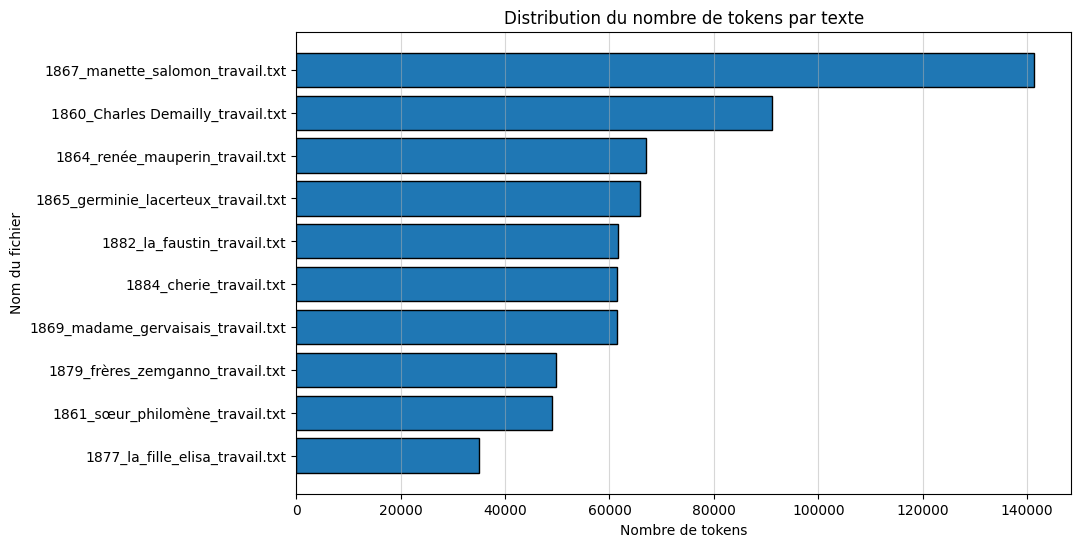

In [5]:
df_plot = df.sort_values("nb_tokens")

plt.figure(figsize=(10, 6))
plt.barh(df_plot["nom_fichier"], df_plot["nb_tokens"], edgecolor="black")
plt.title("Distribution du nombre de tokens par texte")
plt.xlabel("Nombre de tokens")
plt.ylabel("Nom du fichier")
plt.grid(axis="x", alpha=0.5)
plt.show()

# Netoyage du texte 

In [6]:
def segmenter_texte(text, taille=300): # On segmente le texte en segments de 300 mots
    mots = text.split()
    segments = []
    for i in range(0, len(mots), taille):
        segment = " ".join(mots[i:i+taille])
        if len(segment.split()) >= 100: 
            segments.append(segment)
    return segments

lignes = [] # Liste pour stocker les segments de texte avec leurs titres et IDs

for _, row in df.iterrows():
    titre = row["nom_fichier"] # On utilise le nom du fichier comme titre
    texte = row["texte_brut"] # On segmente le texte en segments de 300 mots
    segments = segmenter_texte(texte) # On ajoute chaque segment à la liste avec son titre et son ID
    
    for j, seg in enumerate(segments):
        
        
        lignes.append({ 
            "titre": titre, # Titre du texte (nom du fichier)
            "segment_id": j, # ID du segment (index du segment dans le texte)
            "texte_segment": seg # Contenu du segment de texte
        })

df_segments = pd.DataFrame(lignes) # Création d'un DataFrame à partir de la liste de segments

df_segments

,titre,segment_id,texte_segment
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait..."
1,1869_madame_gervaisais_travail.txt,1,"suivent… — Oui, signora… Nous, nous nous retir..."
2,1869_madame_gervaisais_travail.txt,2,et trempant la plume dans la boue d’un encrier...
3,1869_madame_gervaisais_travail.txt,3,"sa vie, Jules demandait à Edmond de lui en fai..."
4,1869_madame_gervaisais_travail.txt,4,place des touristes consciencieux lisaient le ...
...,...,...,...
2275,1864_renée_mauperin_travail.txt,219,"à son aise, dans son coin, la tête contre le m..."
2276,1864_renée_mauperin_travail.txt,220,disaient bientôt plus rien ; ils restaient mue...
2277,1864_renée_mauperin_travail.txt,221,trempaient dans la lumière le bord de leurs fe...
2278,1864_renée_mauperin_travail.txt,222,"cinq sous, des joujoux gagnés à des loteries, ..."


# Phase de traitement de textes


In [7]:
stop_word = {
    "bon", "bien", "tout", "toute", "tous", "toutes",
    "grand", "petit", "autre", "même", "seul",
    "faire", "aller", "venir", "voir", "dire", "savoir",
    "vouloir", "pouvoir", "falloir", "prendre", "mettre",
    "tenir", "donner", "parler", "trouver", "rester",
    "sembler", "penser", "avoir", "être",
    "chose", "fois",
    "monsieur", "madame", "mademoiselle", "mme", "mlle",
    "cher", "vrai", "renée", "croire",
    "villacourt", "maréchal", "vaudevilliste"
}
# On peut ajouter d'autres stop words spécifiques au corpus ou à la langue française selon les besoins.

In [8]:
def nettoyer_texte(texte): #  Fonction pour nettoyer le texte : suppression des stop words, ponctuation, chiffres, espaces, et lemmatisation
    doc = nlp(texte) # Traiter le texte avec spaCy pour obtenir les tokens et leurs propriétés
    tokens = [] # Liste pour stocker les tokens nettoyés
    
    for token in doc:
        lemme = token.lemma_.lower()
        
        if (
            not token.is_stop # Ignorer les stop words (mots vides par défaut dans spaCy)
            and not token.is_punct # Ignorer la ponctuation
            and not token.like_num # Ignorer les chiffres
            and not token.is_space # Ignorer les espaces
            and token.pos_ in {"NOUN", "ADJ"} # Ne garder que les noms et adjectifs
            and len(token.lemma_) > 3 # Ne garder que les tokens dont la longueur du lemme est supérieure à 3 caractères
            and lemme not in stop_word
        ):
            tokens.append(lemme) # Ajouter le lemme du token en minuscules à la liste des tokens nettoyés
    
    return " ".join(tokens) # Retourner le texte nettoyé en joignant les tokens avec des espaces

df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte) # Application de la fonction de nettoyage à chaque segment de texte

df_segments[["texte_segment", "texte_nettoye"]].head() # Affichage des 5 premiers segments avant et après nettoyage



,texte_segment,texte_nettoye
0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...
1,"suivent… — Oui, signora… Nous, nous nous retir...",chambre fond besoin mère romaine vieux femme s...
2,et trempant la plume dans la boue d’un encrier...,plume boue encrier reçu étranger carte gervais...
3,"sa vie, Jules demandait à Edmond de lui en fai...",lecture haut mémoire idée manie matin soir fig...
4,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...


In [9]:
df_segments["nb_tokens_nettoyes"] = df_segments["texte_nettoye"].apply(lambda x: len(x.split())) # Calcul du nombre de tokens nettoyés pour chaque segment
df_segments["nb_tokens_nettoyes"].describe() # Affichage des statistiques descriptives du nombre de tokens nettoyés par segment (moyenne, écart-type, min, max, etc.)

count    2280.000000
mean       74.469737
std        17.300913
min        23.000000
25%        62.000000
50%        75.000000
75%        87.000000
max       121.000000
Name: nb_tokens_nettoyes, dtype: float64

In [35]:
vectorizer = TfidfVectorizer( 
    min_df=3,
    max_df=0.8
    )
# min_df=5 : Ignorer les termes qui apparaissent dans moins de 5 segments, car ils sont considérés comme peu informatifs.
# max_df=0.8 : Ignorer les termes qui apparaissent dans plus de 80% des segments, car ils sont trop fréquents et ne contribuent pas à différencier les segments.

X = vectorizer.fit_transform(df_segments["texte_nettoye"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(2280, 6235)

In [36]:
def afficher_topics(model, feature_names, n_top_words=8): 
# Fonction pour afficher les topics extraits par le modèle NMF, en affichant les n_top_words les plus importants pour chaque topic.

    for topic_idx, topic in enumerate(model.components_): 
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")
        
        
feature_names = vectorizer.get_feature_names_out() # Récupérer les noms des caractéristiques (termes) à partir du vectorizer pour pouvoir les afficher dans les topics.

for k in [8, 10, 12]: # Tester différents nombres de topics (8, 10, 12) pour voir comment cela affecte les résultats de l'extraction de topics avec NMF.

    print(f"\n NMF avec {k} topics") 

    nmf = NMF(n_components=k, # Nombre de topics à extraire
              init="nndsvda", # Utiliser l'initialisation "nndsvda" pour une meilleure convergence du modèle NMF, surtout avec des données de texte.
              random_state=42, # Fixer une graine aléatoire pour assurer la reproductibilité des résultats de l'extraction de topics avec NMF.
              max_iter=600 # Augmenter le nombre maximum d'itérations pour permettre au modèle de mieux converger, surtout si les données sont complexes ou si le nombre de topics est élevé.
              )

    W = nmf.fit_transform(X) # Appliquer le modèle NMF sur la matrice de caractéristiques pour extraire les topics et obtenir la matrice W (représentation des segments dans l'espace des topics).
    afficher_topics(nmf, feature_names, 10) # Afficher les 10 mots les plus importants pour chaque topic extrait par le modèle NMF.

    print("Erreur :", nmf.reconstruction_err_)
    # Afficher l'erreur de reconstruction du modèle NMF, qui mesure à quel point le modèle parvient à reconstruire la matrice d'origine 
    # à partir des facteurs extraits. Une erreur plus faible indique une meilleure qualité de l'extraction de topics.


 NMF avec 8 topics
Topic 1 : femme | amour | homme | jeune | fille | cœur | maîtresse | monde | pensée | mari
Topic 2 : ciel | arbre | soleil | ombre | bois | blanc | lumière | terre | bleu | noir
Topic 3 : sœur | malade | salle | interne | hôpital | voix | garde | médecin | service | main
Topic 4 : franc | homme | argent | journal | idée | monde | livre | talent | atelier | cent
Topic 5 : frère | cirque | exercice | pied | saut | tour | directeur | aîné | clown | tonneau
Topic 6 : heure | jour | chambre | temps | nuit | mort | matin | dîner | soir | journée
Topic 7 : main | tête | oeil | bras | femme | cheveu | blanc | noir | pied | corps
Topic 8 : enfant | mère | fille | père | fils | jeune | pauvre | famille | cœur | mariage
Erreur : 46.188661120296075

 NMF avec 10 topics
Topic 1 : pensée | cœur | amour | parole | mort | idée | esprit | souffrance | jour | maladie
Topic 2 : ciel | arbre | soleil | ombre | blanc | bois | lumière | bleu | terre | noir
Topic 3 : sœur | malade | salle

In [37]:
nmf = NMF(n_components=12, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
          )
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : pensée | cœur | mort | parole | amour | souffrance | jour | idée | maladie | corps
Topic 2 : ciel | arbre | soleil | ombre | bois | blanc | lumière | terre | bleu | noir
Topic 3 : sœur | malade | salle | interne | hôpital | garde | médecin | voix | service | main
Topic 4 : enfant | mère | fils | père | pauvre | cœur | famille | jour | oeil | maman
Topic 5 : frère | cirque | exercice | pied | saut | tour | aîné | tonneau | clown | directeur
Topic 6 : heure | jour | chambre | dîner | temps | matin | maison | nuit | porte | soir
Topic 7 : main | tête | oeil | bras | cheveu | pied | noir | corps | blanc | regard
Topic 8 : fille | jeune | père | mariage | monde | amie | année | salon | petite | joli
Topic 9 : homme | journal | idée | talent | artiste | tableau | œuvre | atelier | monde | peintre
Topic 10 : femme | homme | amour | maîtresse | mari | amant | ménage | créature | espèce | monde
Topic 11 : théâtre | acteur | scène | pièce | rôle | tragédien | loge | directeur | voix | 

In [38]:
nmf = NMF(
    n_components=12,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

W = nmf.fit_transform(X)

df_segments["topic_dominant"] = W.argmax(axis=1)
df_segments["poids_topic"] = W.max(axis=1)

In [39]:
for topic in sorted(df_segments["topic_dominant"].unique()):
    print(f"\n TOPIC {topic} ")
    subset = (
        df_segments[df_segments["topic_dominant"] == topic]
        .sort_values("poids_topic", ascending=False)
        .head(5)
    )
    for _, row in subset.iterrows():
        print(f"\nTitre : {row['titre']} | Segment : {row['segment_id']} | Poids : {row['poids_topic']:.4f}")
        print(row["texte_segment"][:500])


 TOPIC 0 

Titre : 1861_sœur_philomène_travail.txt | Segment : 32 | Poids : 0.1257
et s’amaigrissaient. Un malaise général, des souffrances qui se déplaçaient tous les jours lui donnaient continuellement un sentiment douloureux de toutes les parties de son corps, la conscience et la fatigue du jeu laborieux de ses organes, du travail de la vie dans son être. Elle était abattue en se levant, faible d’une faiblesse qu’elle ne pouvait surmonter. Quand elle montait des escaliers ou qu’elle courait, elle avait des battements de cœur : lui fallait s’asseoir. Le moindre travail lui d

Titre : 1882_la_faustin_travail.txt | Segment : 200 | Poids : 0.1209
elle mangerait, elle n'aurait plus son visage en face d'elle ; et, quand elle dormirait, elle n'aurait plus son sommeil lié au sien ; et elle n'aurait plus sa parole pour dire la même pensée que celle venue au même moment dans sa tête ; et elle n'aurait plus ses yeux pour voir, pour voir à deux... Non, plus rien désormais dans sa vie que l'épo

In [40]:
df_segments

,titre,segment_id,texte_segment,texte_nettoye,nb_tokens_nettoyes,topic_dominant,poids_topic,topic_label,Champs_lexical
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...,64,11,0.217917,12,argent et affaires
1,1869_madame_gervaisais_travail.txt,1,"suivent… — Oui, signora… Nous, nous nous retir...",chambre fond besoin mère romaine vieux femme s...,62,11,0.087339,12,argent et affaires
2,1869_madame_gervaisais_travail.txt,2,et trempant la plume dans la boue d’un encrier...,plume boue encrier reçu étranger carte gervais...,58,3,0.117126,4,"famille, enfance et pauvreté"
3,1869_madame_gervaisais_travail.txt,3,"sa vie, Jules demandait à Edmond de lui en fai...",lecture haut mémoire idée manie matin soir fig...,67,2,0.040714,3,maladie et espace hospitalier
4,1869_madame_gervaisais_travail.txt,4,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...,105,7,0.028095,8,mariage et sociabilité
...,...,...,...,...,...,...,...,...,...
2275,1864_renée_mauperin_travail.txt,219,"à son aise, dans son coin, la tête contre le m...",aise coin tête doux courage premier mois insta...,51,0,0.073984,1,"intériorité, souffrance et mort"
2276,1864_renée_mauperin_travail.txt,220,disaient bientôt plus rien ; ils restaient mue...,muet ciel soir main fille temps temps obscurit...,85,1,0.117285,2,paysage et lumière
2277,1864_renée_mauperin_travail.txt,221,trempaient dans la lumière le bord de leurs fe...,lumière bord feuille miroir garni velours bleu...,88,1,0.066011,2,paysage et lumière
2278,1864_renée_mauperin_travail.txt,222,"cinq sous, des joujoux gagnés à des loteries, ...",joujou loterie animal pain four patte allumett...,88,6,0.072253,7,cirque et performance


In [41]:
df_segments["topic_dominant"] = W.argmax(axis=1) # On trouve l'indice du topic dominant pour chaque segment en prenant l'index du poids maximum dans la matrice W
df_segments["topic_label"] = df_segments["topic_dominant"] + 1 # On crée une nouvelle colonne "topic_label" qui correspond au numéro du topic (en ajoutant 1 pour que les numéros commencent à 1 au lieu de 0)

df_segments.drop('topic_dominant', axis='columns') 

,titre,segment_id,texte_segment,texte_nettoye,nb_tokens_nettoyes,poids_topic,topic_label,Champs_lexical
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...,64,0.217917,12,argent et affaires
1,1869_madame_gervaisais_travail.txt,1,"suivent… — Oui, signora… Nous, nous nous retir...",chambre fond besoin mère romaine vieux femme s...,62,0.087339,12,argent et affaires
2,1869_madame_gervaisais_travail.txt,2,et trempant la plume dans la boue d’un encrier...,plume boue encrier reçu étranger carte gervais...,58,0.117126,4,"famille, enfance et pauvreté"
3,1869_madame_gervaisais_travail.txt,3,"sa vie, Jules demandait à Edmond de lui en fai...",lecture haut mémoire idée manie matin soir fig...,67,0.040714,3,maladie et espace hospitalier
4,1869_madame_gervaisais_travail.txt,4,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...,105,0.028095,8,mariage et sociabilité
...,...,...,...,...,...,...,...,...
2275,1864_renée_mauperin_travail.txt,219,"à son aise, dans son coin, la tête contre le m...",aise coin tête doux courage premier mois insta...,51,0.073984,1,"intériorité, souffrance et mort"
2276,1864_renée_mauperin_travail.txt,220,disaient bientôt plus rien ; ils restaient mue...,muet ciel soir main fille temps temps obscurit...,85,0.117285,2,paysage et lumière
2277,1864_renée_mauperin_travail.txt,221,trempaient dans la lumière le bord de leurs fe...,lumière bord feuille miroir garni velours bleu...,88,0.066011,2,paysage et lumière
2278,1864_renée_mauperin_travail.txt,222,"cinq sous, des joujoux gagnés à des loteries, ...",joujou loterie animal pain four patte allumett...,88,0.072253,7,cirque et performance


In [42]:
df_segments["topic_label"].value_counts().sort_index()

topic_label
1     162
2     312
3     126
4     155
5     106
6     232
7     295
8     158
9     243
10    219
11    144
12    128
Name: count, dtype: int64

In [43]:
topic_names = {
    1: "intériorité, souffrance et mort",
    2: "paysage et lumière",
    3: "maladie et espace hospitalier",
    4: "famille, enfance et pauvreté",
    5: "quotidien domestique et temporalité",
    6: "corps et perception",
    7: "cirque et performance",
    8: "mariage et sociabilité",
    9: "art et monde intellectuel",
    10: "amour et relation",
    11: "théâtre et scène",
    12: "argent et affaires"
}

In [44]:
df_segments["Champs_lexical"] = df_segments["topic_label"].map(topic_names)

df_segments

,titre,segment_id,texte_segment,texte_nettoye,nb_tokens_nettoyes,topic_dominant,poids_topic,topic_label,Champs_lexical
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...,64,11,0.217917,12,argent et affaires
1,1869_madame_gervaisais_travail.txt,1,"suivent… — Oui, signora… Nous, nous nous retir...",chambre fond besoin mère romaine vieux femme s...,62,11,0.087339,12,argent et affaires
2,1869_madame_gervaisais_travail.txt,2,et trempant la plume dans la boue d’un encrier...,plume boue encrier reçu étranger carte gervais...,58,3,0.117126,4,"famille, enfance et pauvreté"
3,1869_madame_gervaisais_travail.txt,3,"sa vie, Jules demandait à Edmond de lui en fai...",lecture haut mémoire idée manie matin soir fig...,67,2,0.040714,3,maladie et espace hospitalier
4,1869_madame_gervaisais_travail.txt,4,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...,105,7,0.028095,8,mariage et sociabilité
...,...,...,...,...,...,...,...,...,...
2275,1864_renée_mauperin_travail.txt,219,"à son aise, dans son coin, la tête contre le m...",aise coin tête doux courage premier mois insta...,51,0,0.073984,1,"intériorité, souffrance et mort"
2276,1864_renée_mauperin_travail.txt,220,disaient bientôt plus rien ; ils restaient mue...,muet ciel soir main fille temps temps obscurit...,85,1,0.117285,2,paysage et lumière
2277,1864_renée_mauperin_travail.txt,221,trempaient dans la lumière le bord de leurs fe...,lumière bord feuille miroir garni velours bleu...,88,1,0.066011,2,paysage et lumière
2278,1864_renée_mauperin_travail.txt,222,"cinq sous, des joujoux gagnés à des loteries, ...",joujou loterie animal pain four patte allumett...,88,6,0.072253,7,cirque et performance


In [45]:
df_segments["Champs_lexical"].value_counts()

Champs_lexical
paysage et lumière                     312
cirque et performance                  295
art et monde intellectuel              243
corps et perception                    232
amour et relation                      219
intériorité, souffrance et mort        162
mariage et sociabilité                 158
famille, enfance et pauvreté           155
théâtre et scène                       144
argent et affaires                     128
maladie et espace hospitalier          126
quotidien domestique et temporalité    106
Name: count, dtype: int64

In [47]:
tableau_contingence = pd.crosstab(
    df_segments["titre"],
    df_segments["Champs_lexical"],
    normalize="index"
) * 100

tableau_contingence.round(2)

Champs_lexical,amour et relation,argent et affaires,art et monde intellectuel,cirque et performance,corps et perception,"famille, enfance et pauvreté","intériorité, souffrance et mort",maladie et espace hospitalier,mariage et sociabilité,paysage et lumière,quotidien domestique et temporalité,théâtre et scène
titre,,,,,,,,,,,,
1860_Charles Demailly_travail.txt,11.18,8.22,31.58,8.88,7.89,2.63,5.59,0.33,1.32,11.84,0.33,10.20
1861_sœur_philomène_travail.txt,3.68,0.61,0.61,10.43,6.13,4.91,15.95,47.85,1.84,7.98,0.00,0.00
1864_renée_mauperin_travail.txt,5.36,12.05,8.04,13.39,9.38,16.52,3.57,1.79,13.39,9.82,3.12,3.57
1865_germinie_lacerteux_travail.txt,8.64,9.09,0.91,14.09,19.55,13.64,12.73,4.55,6.36,8.18,0.91,1.36
1867_manette_salomon_travail.txt,10.83,7.43,23.57,15.92,15.29,2.97,2.55,0.00,1.27,19.53,0.21,0.42
1869_madame_gervaisais_travail.txt,4.88,1.46,4.39,8.78,6.83,16.59,20.00,1.95,2.93,27.80,2.93,1.46
1877_la_fille_elisa_travail.txt,29.91,0.85,0.85,11.97,9.40,5.13,10.26,5.98,5.98,17.09,0.00,2.56
1879_frères_zemganno_travail.txt,2.41,4.82,0.60,16.87,1.81,3.61,1.20,0.00,1.81,9.04,53.61,4.22
1882_la_faustin_travail.txt,13.17,2.93,0.49,13.17,8.29,0.98,2.93,9.27,0.98,7.32,0.00,40.49


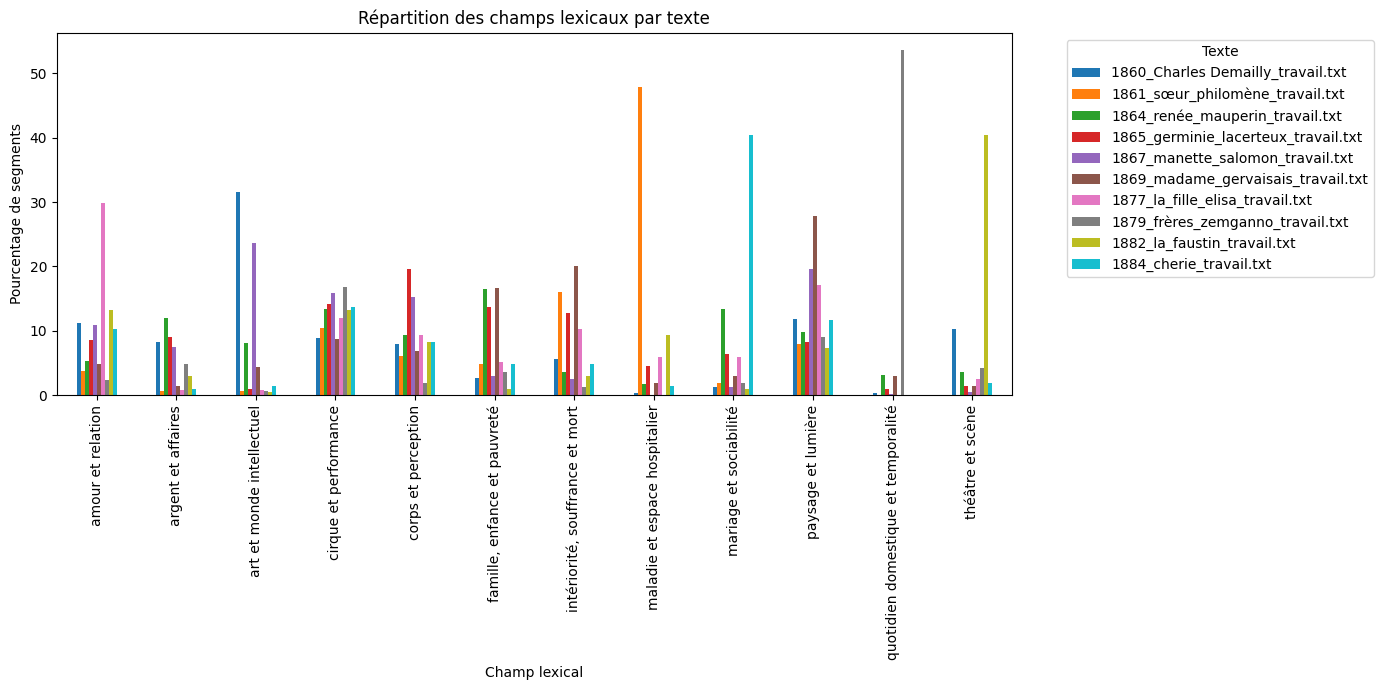

In [49]:
tableau_contingence.T.plot(kind="bar", figsize=(14, 7))
plt.title("Répartition des champs lexicaux par texte")
plt.xlabel("Champ lexical")
plt.ylabel("Pourcentage de segments")
plt.legend(title="Texte", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()